In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print('All Libraries imported successfully!')

All Libraries imported successfully!


In [2]:
df=pd.read_csv('retail_sales.csv')
df.head(20)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


In [3]:
print("=== Basic Dataset Information")
print(f"\nDataset Dimensions {df.shape[0]} rows * {df.shape[1]} columns")
print("\nColumn names and Data types")
print(df.dtypes)

=== Basic Dataset Information

Dataset Dimensions 1825 rows * 6 columns

Column names and Data types
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


In [4]:
print("\nMissing Values")
print(df.isna().sum())
print("\nDataset Summary")
print(df.info())



Missing Values
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

Dataset Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB
None


In [20]:
df.loc[df['Region'].isna() & df['Quantity'].isna()]

,Date,Category,Sales,Quantity,Profit,Region
13,1/3/2023,Sports,0.0,NaN,371.526571,NaN


In [5]:
df.dropna(subset=['Region', 'Quantity'], how='all', inplace=True)

In [6]:
df.iloc[13]

Date           1/3/2023
Category          Books
Sales       1232.110125
Quantity           13.0
Profit       175.301262
Region             East
Name: 14, dtype: object

In [7]:
df.isna().sum()

Date        0
Category    4
Sales       2
Quantity    4
Profit      0
Region      4
dtype: int64

In [29]:
df.loc[df['Sales'].isna()]

,Date,Category,Sales,Quantity,Profit,Region
45,1/10/2023,Electronics,NaN,19.0,258.220661,East
153,1/31/2023,Sports,NaN,5.0,561.819281,North


In [36]:
electronics_mean=df.loc[df['Category']=='Electronics','Sales'].agg('mean')
sports_mean=df.loc[df['Category']=='Sports','Sales'].agg('mean')

In [8]:
df['Sales']=df['Sales'].fillna(
df.groupby('Category')['Sales'].transform('mean'))

In [9]:
df.loc[df['Sales'].isna()]

,Date,Category,Sales,Quantity,Profit,Region


In [47]:
df.loc[df['Region'].isna() | df['Quantity'].isna()]

,Date,Category,Sales,Quantity,Profit,Region
27,1/6/2023,Home Goods,1686.167795,19.0,250.170622,NaN
33,1/7/2023,Sports,625.000000,NaN,108.302446,East
43,1/9/2023,Sports,993.435738,NaN,144.262032,East
48,1/10/2023,Sports,1061.695040,NaN,188.326108,West
73,1/15/2023,Sports,1533.677303,NaN,552.310471,North
87,1/18/2023,Home Goods,1173.369141,3.0,204.540884,NaN
113,1/23/2023,Sports,1121.374869,12.0,403.762921,NaN
138,1/28/2023,Sports,0.000000,5.0,439.982225,NaN


In [10]:
df['Region'].value_counts()

Region
South    484
West     477
North    460
East     398
Nan        1
Name: count, dtype: int64

In [11]:
df['Region'].fillna('Unknown', inplace=True)

In [12]:
df['Region']=df['Region'].replace(['Nan'],'Unknown')

In [13]:
df.loc[df['Region'] == 'Unknown']

,Date,Category,Sales,Quantity,Profit,Region
27,1/6/2023,Home Goods,1686.167795,19.0,250.170622,Unknown
80,1/17/2023,Electronics,1716.710787,8.0,545.617726,Unknown
87,1/18/2023,Home Goods,1173.369141,3.0,204.540884,Unknown
113,1/23/2023,Sports,1121.374869,12.0,403.762921,Unknown
138,1/28/2023,Sports,0.000000,5.0,439.982225,Unknown


In [53]:
df.loc[df['Category'].isna() | df['Quantity'].isna()]

,Date,Category,Sales,Quantity,Profit,Region
10,1/3/2023,NaN,1246.763474,2.0,283.696992,South
15,1/4/2023,NaN,839.000000,13.0,102.610251,East
18,1/4/2023,NaN,1142.812776,10.0,237.179042,North
33,1/7/2023,Sports,625.000000,NaN,108.302446,East
43,1/9/2023,Sports,993.435738,NaN,144.262032,East
48,1/10/2023,Sports,1061.695040,NaN,188.326108,West
73,1/15/2023,Sports,1533.677303,NaN,552.310471,North
90,1/19/2023,NaN,1209.727715,4.0,183.830902,South


In [14]:
df['Category'].value_counts()

Category
Clothing       365
Home Goods     364
Books          364
Sports         363
Electronics    361
NaN?             1
Null             1
Nan              1
Name: count, dtype: int64

In [15]:
df['Category']=df['Category'].fillna('Unknown')

In [16]:
df['Category']=df['Category'].replace(['NaN?','Nan','Null'],'Unknown')

In [17]:
df.groupby('Category')['Quantity'].agg(['mean','median'])

,mean,median
Category,,
Books,10.266484,10.0
Clothing,9.975342,10.0
Electronics,9.958449,10.0
Home Goods,10.376374,11.0
Sports,9.727019,10.0
Unknown,8.000000,10.0


In [18]:
df['Quantity']=df['Quantity'].fillna(
df.groupby('Category')['Quantity'].transform('median'))

In [19]:
df.head(20)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,Unknown,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


## Handling Missing Values:

**Sales missing data was imputed with mean of each category**

**Category and Region were replaced with 'Unknown' wherever missing/invalid value was present**

**Quantity was imputed with the median quantity of each category**


In [20]:
print("\nMissing Values")
print(df.isna().sum())
print("\nDataset Summary")
print(df.info())



Missing Values
Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64

Dataset Summary
<class 'pandas.core.frame.DataFrame'>
Index: 1824 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1824 non-null   object 
 1   Category  1824 non-null   object 
 2   Sales     1824 non-null   float64
 3   Quantity  1824 non-null   float64
 4   Profit    1824 non-null   float64
 5   Region    1824 non-null   object 
dtypes: float64(3), object(3)
memory usage: 99.8+ KB
None


In [21]:
print(" === TYPE CONVERSION === ")

df['Date']=pd.to_datetime(df['Date'])

df['Month']= df['Date'].dt.month
df['Quarter']=  df['Date'].dt.quarter
df['DayofWeek'] =  df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

print("\nDate Types After Conversion")
print(df.dtypes)
print(f"\nDate Range {df['Date'].min()} to {df['Date'].max()}")

 === TYPE CONVERSION === 

Date Types After Conversion
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayofWeek            object
MonthName            object
dtype: object

Date Range 2023-01-01 00:00:00 to 2023-12-31 00:00:00


In [76]:
print(" === STATISTICAL SUMMARY === ")
print('\nDescriptive Statistics for Numerical Columns:')
df[['Sales','Profit','Quantity']].describe()


 === STATISTICAL SUMMARY === 

Descriptive Statistics for Numerical Columns:


,Sales,Profit,Quantity
count,1824.000000,1824.000000,1824.000000
mean,981.024658,248.628789,10.053728
std,335.880905,118.156995,5.509317
min,0.000000,0.000000,0.000000
25%,784.316448,156.907646,5.000000
50%,997.735262,229.212567,10.000000
75%,1208.338127,323.760291,15.000000
max,1888.932537,703.228418,19.000000


In [23]:
print("\n\t\t\t Category-wise Summary \t\t\t")

category_summary= df.groupby('Category').agg({
    'Sales':['count','sum','mean','std'],
    'Quantity': ['sum','mean'],
    'Profit':['sum','mean']
}).round(2)
category_summary


			 Category-wise Summary 			


Sales                             Quantity           Profit  \
            count        sum     mean     std      sum   mean       sum   
Category                                                                  
Books         364  370971.87  1019.15  336.39   3737.0  10.27  92304.45   
Clothing      365  350981.82   961.59  337.49   3641.0   9.98  90082.12   
Electronics   361  365101.77  1011.36  343.77   3595.0   9.96  90439.70   
Home Goods    364  347493.83   954.65  332.39   3777.0  10.38  87447.82   
Sports        363  347642.76   957.69  327.36   3532.0   9.73  91693.69   
Unknown         7    7196.93  1028.13  190.49     56.0   8.00   1531.13   

                     
               mean  
Category             
Books        253.58  
Clothing     246.80  
Electronics  250.53  
Home Goods   240.24  
Sports       252.60  
Unknown      218.73

In [24]:
print("\n\t\t\t Region-wise Summary \t\t\t")

region_summary= df.groupby('Region').agg({
    'Sales':['count','sum','mean','std'],
    'Profit':['sum','mean']
}).round(2)
region_summary


			 Region-wise Summary 			


Sales                                 Profit        
        count        sum     mean     std        sum    mean
Region                                                      
East      398  394452.98   991.09  318.83   98973.62  248.68
North     460  449252.73   976.64  314.31  112126.47  243.75
South     484  469471.28   969.98  355.69  118036.97  243.88
Unknown     5    5697.62  1139.52  694.97    1844.07  368.81
West      477  470514.37   986.40  345.06  122517.78  256.85

In [25]:
print("\n\t\t\t Monthly Sales Trend Analysis \t\t\t")

monthly_sales= df.groupby(['Month','MonthName']).agg({
    'Sales':'sum',
    'Quantity':'sum',
    'Profit':'sum'
}).round(2).reset_index()

monthly_sales= monthly_sales.sort_values('Month')
print("\n Monthly Sales Summary")
monthly_sales



			 Monthly Sales Trend Analysis 			

 Monthly Sales Summary


,Month,MonthName,Sales,Quantity,Profit
0,1,January,149037.68,1526.0,39339.91
1,2,February,132215.41,1517.0,34353.12
2,3,March,145321.20,1447.0,38584.60
3,4,April,138160.99,1446.0,37895.20
4,5,May,150774.98,1603.0,40527.69
5,6,June,152605.75,1570.0,39042.69
6,7,July,162111.12,1536.0,40208.96
7,8,August,148020.45,1489.0,34675.63
8,9,September,153094.70,1598.0,37796.76
9,10,October,151272.28,1569.0,36019.38


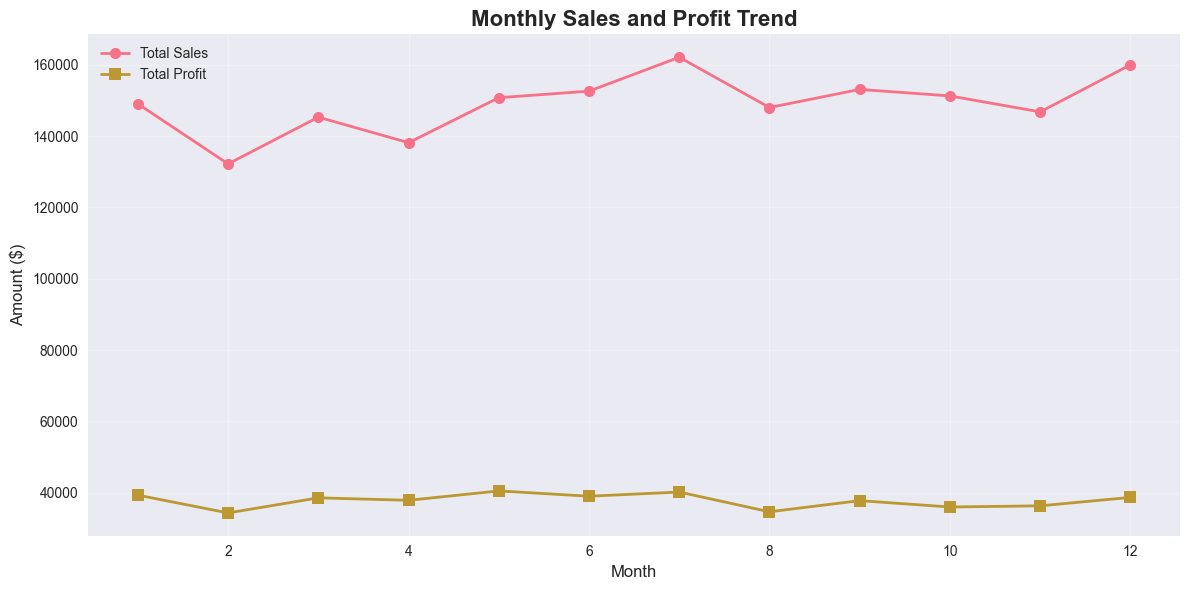

In [26]:
# Visualization: Monthly Sales Trend

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'],marker='o', linewidth=2, markersize=8, label='Total Sales')
plt.plot(monthly_sales['Month'], monthly_sales['Profit'],marker='s', linewidth=2, markersize=8, label='Total Profit')

plt.title('Monthly Sales and Profit Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
print(" === CATEGORY PERFORMANCE ANALYSIS ===")

category_performance= df.groupby('Category').agg({
    'Sales':'sum',
    'Quantity': 'sum',
    'Profit':'sum'
    }).sort_values('Sales', ascending=False)
print("\nCategory Performance (Sorted by Sales)")
category_performance

 === CATEGORY PERFORMANCE ANALYSIS ===

Category Performance (Sorted by Sales)


,Sales,Quantity,Profit
Category,,,
Books,370971.872558,3737.0,92304.452141
Electronics,365101.768528,3595.0,90439.697795
Clothing,350981.822773,3641.0,90082.119920
Sports,347642.756843,3532.0,91693.694280
Home Goods,347493.827088,3777.0,87447.820056
Unknown,7196.928437,56.0,1531.126421


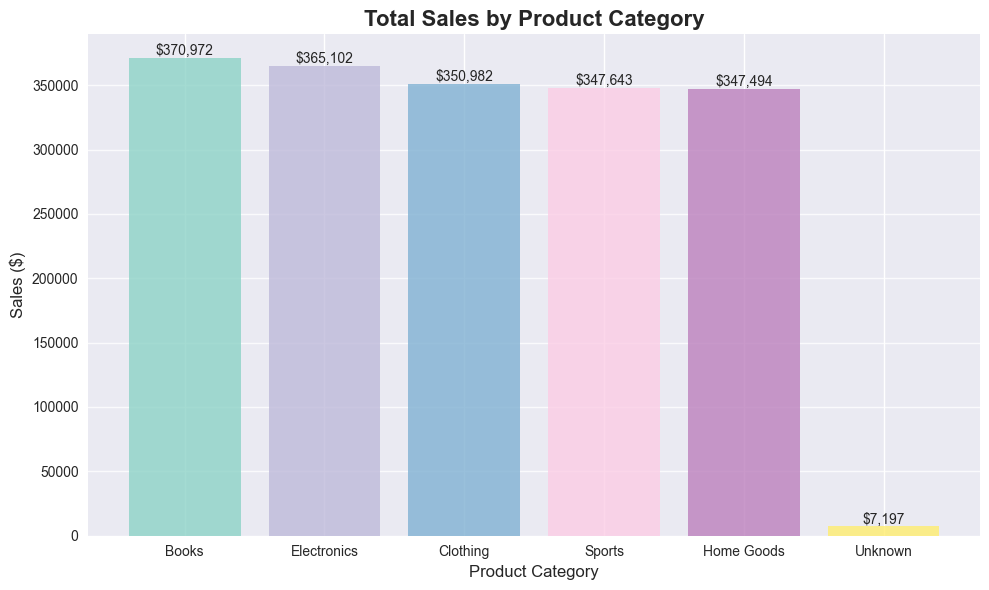

In [38]:
plt.figure(figsize=(10,6))
colors= plt.cm.Set3(np.linspace(0,1,len(category_performance)))
bars = plt.bar(category_performance.index, category_performance['Sales'], color = colors, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va= 'bottom')
    

plt.title("Total Sales by Product Category", fontweight= 'bold', fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)
plt.grid(axis='y', alpha=0.8)
plt.tight_layout()
plt.show()

In [39]:
print(" === REGION PERFORMANCE ANALYSIS ===")

region_performance= df.groupby('Region').agg({
    'Sales':'sum',
    'Profit':'sum'
    }).round(2)
print("\nRegion Performance (Sorted by Sales)")
region_performance

 === REGION PERFORMANCE ANALYSIS ===

Region Performance (Sorted by Sales)


,Sales,Profit
Region,,
East,394452.98,98973.62
North,449252.73,112126.47
South,469471.28,118036.97
Unknown,5697.62,1844.07
West,470514.37,122517.78


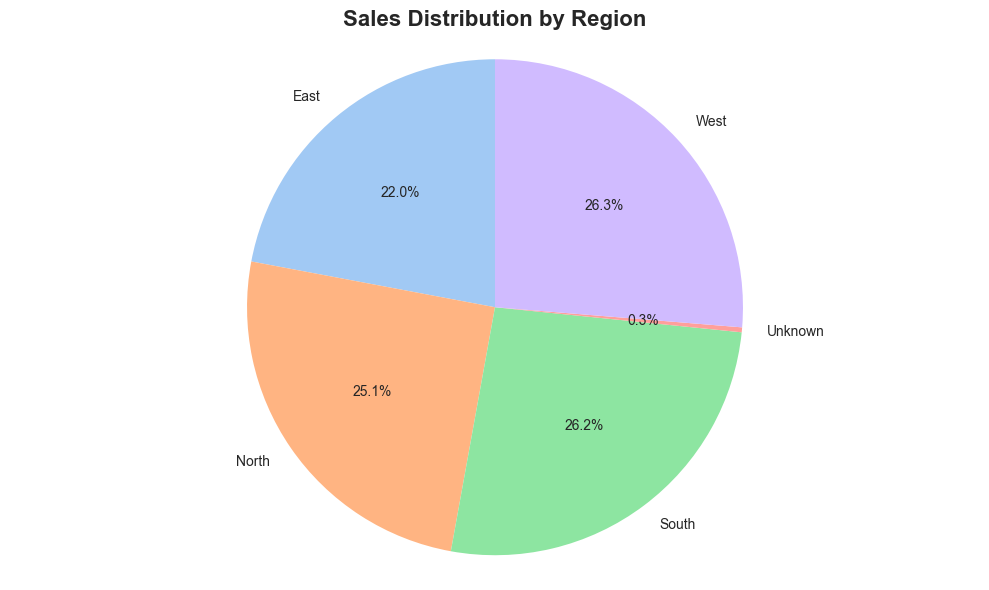

In [45]:
plt.figure(figsize=(10,6))
regional_data=df.groupby('Region')['Sales'].sum()
plt.pie(regional_data,labels=regional_data.index, autopct='%1.1f%%',startangle=90, colors=sns.color_palette('pastel'))
plt.title('Sales Distribution by Region', fontweight='bold', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

 === DAY OF WEEK ANALYSIS === 
Average Performance by Day of Week
             Sales  Profit  Quantity
DayofWeek                           
Monday      981.77  253.32     10.24
Tuesday     985.73  243.69     10.31
Wednesday   965.23  237.57     10.18
Thursday    966.83  237.62      9.78
Friday     1014.31  259.80     10.00
Saturday    972.20  253.32      9.64
Sunday      981.11  254.94     10.22


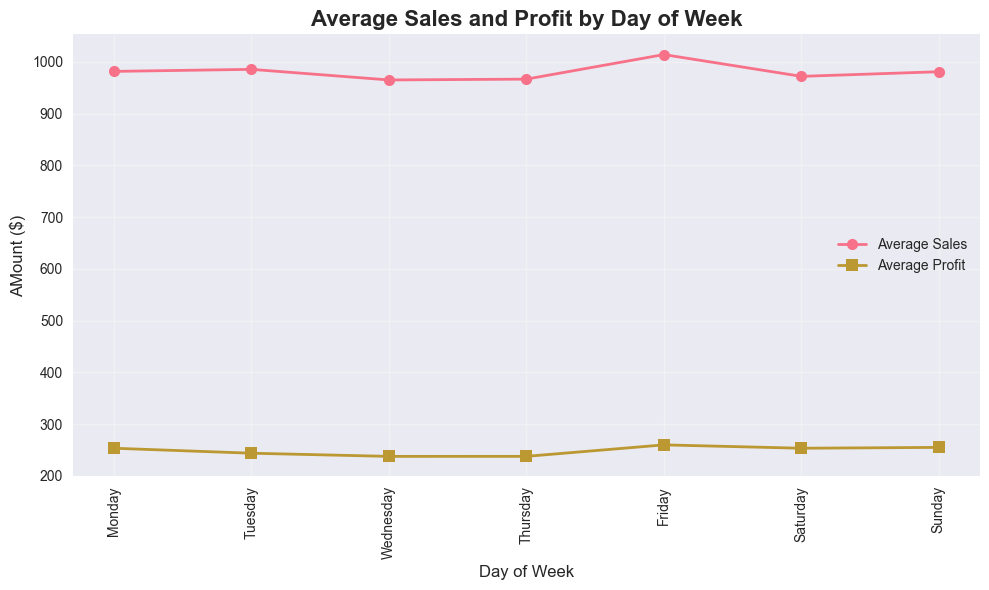

In [50]:
print(" === DAY OF WEEK ANALYSIS === ")

day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['DayofWeek']= pd.Categorical(df['DayofWeek'], categories= day_order, ordered=True)

daily_performance= df.groupby('DayofWeek').agg({
    'Sales':'mean',
    'Profit':'mean',
    'Quantity':'mean'
}).round(2)

print("Average Performance by Day of Week")
print(daily_performance)

plt.figure(figsize=(10,6))
plt.plot(daily_performance.index, daily_performance["Sales"],marker='o', linewidth=2, markersize=8, label='Average Sales')
plt.plot(daily_performance.index, daily_performance["Profit"],marker='s', linewidth=2, markersize=8, label='Average Profit')

plt.title("Average Sales and Profit by Day of Week", fontweight= 'bold', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('AMount ($)', fontsize=12)
plt.legend()
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 === CORRELATION ANALYSIS === 
Correlation Matrix
             Sales    Profit  Quantity     Month
Sales     1.000000  0.526977  0.056820  0.062808
Profit    0.526977  1.000000  0.027806 -0.033798
Quantity  0.056820  0.027806  1.000000  0.003153
Month     0.062808 -0.033798  0.003153  1.000000


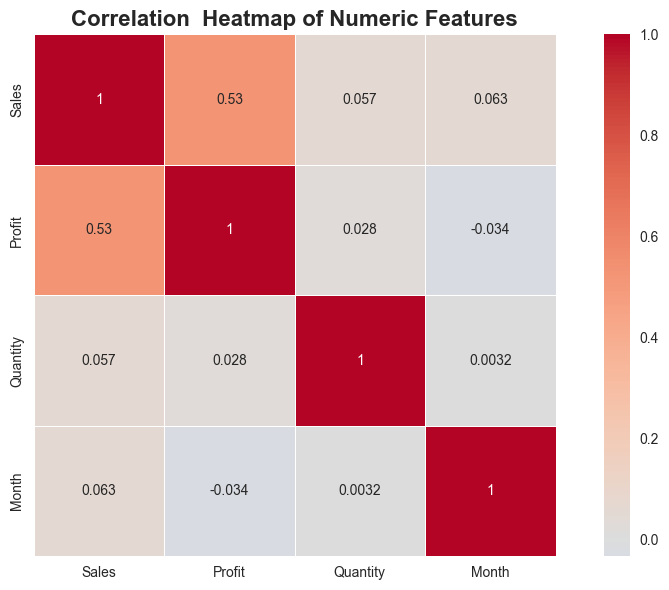

In [53]:
print(" === CORRELATION ANALYSIS === ")

numerical_df= df[['Sales','Profit','Quantity','Month']]
correlation_matrix= numerical_df.corr()

print("Correlation Matrix")
print(correlation_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidth=0.5)

plt.title("Correlation  Heatmap of Numeric Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


			 4-CHART RETAIL SALES DASHBOARD			


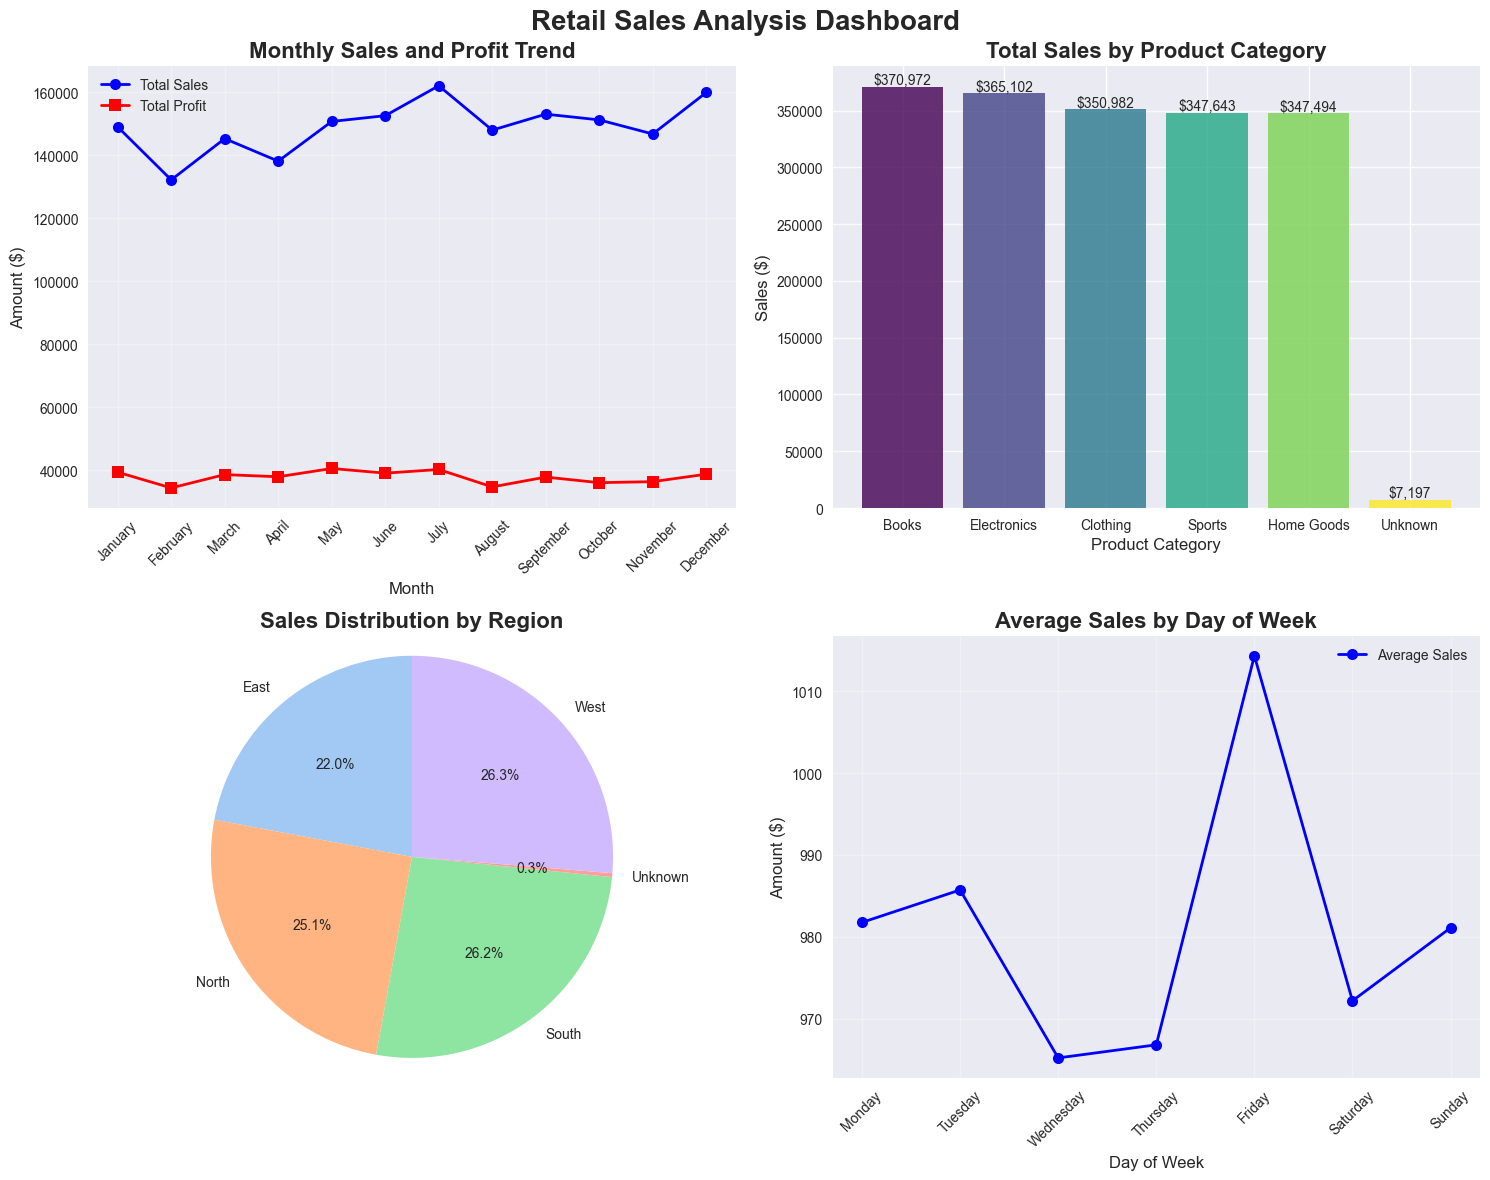

In [66]:
print("\n\t\t\t 4-CHART RETAIL SALES DASHBOARD\t\t\t")
fig, axes= plt.subplots(2,2, figsize=(15,12))
fig.suptitle('Retail Sales Analysis Dashboard', fontsize=20, fontweight='bold')

#plot 1
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Sales'],marker='o', linewidth=2, markersize=8, color='blue', label='Total Sales')
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Profit'],marker='s', linewidth=2, markersize=8,color='red', label='Total Profit')

axes[0,0].set_title('Monthly Sales and Profit Trend', fontsize=16, fontweight='bold')
axes[0,0].set_xlabel('Month', fontsize=12)
axes[0,0].set_ylabel('Amount ($)', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

#plot 2
colors= plt.cm.viridis(np.linspace(0,1,len(category_performance)))
bars = axes[0,1].bar(category_performance.index, category_performance['Sales'], color = colors, alpha=0.8)

for bar in bars:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2, height, f'${height:,.0f}', ha='center', va= 'bottom')
    

axes[0,1].set_title("Total Sales by Product Category", fontweight= 'bold', fontsize=16)
axes[0,1].set_xlabel("Product Category", fontsize=12)
axes[0,1].set_ylabel("Sales ($)", fontsize=12)
axes[0,1].grid(axis='y', alpha=0.8)

#plot 3

axes[1,0].pie(regional_data,labels=regional_data.index, autopct='%1.1f%%',startangle=90, colors=sns.color_palette('pastel'))
axes[1,0].set_title('Sales Distribution by Region', fontweight='bold', fontsize=16)
axes[1,0].axis('equal')

#plot 4
axes[1,1].plot(daily_performance.index, daily_performance["Sales"],marker='o', linewidth=2,color='blue', markersize=8, label='Average Sales')

axes[1,1].set_title("Average Sales by Day of Week", fontweight= 'bold', fontsize=16)
axes[1,1].set_xlabel('Day of Week', fontsize=12)
axes[1,1].set_ylabel('Amount ($)', fontsize=12)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [68]:
#Key Insights and Business Recommendations
print("\n\t\t\t KEY INSIGHTS AND RECOMMENDATIONS \t\t\t")

print("\n📊 KEY FINDINGS:")
print("1. Top Performing Category:", category_performance.index[0])
print("2. Best Performing Region:", regional_data.idxmax())
print("3. Highest Sales Month:", monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'MonthName'])
print("4. Best Day of Week:", daily_performance['Sales'].idxmax())
print("5. Total Annual Sales: ${:,.2f}".format(df['Sales'].sum()))
print("6. Total Annual Profit: ${:,.2f}".format(df['Profit'].sum()))

print("\n💡 BUSINESS RECOMMENDATIONS:")
print("1. Focus marketing efforts on", category_performance.index[0], "category")
print("2. Investigate performance in lower-performing regions")
print("3. Plan promotions around", daily_performance['Sales'].idxmax(), "to maximize sales")
print("4. Allocate inventory based on monthly trend patterns")
print("5. Monitor correlation between quantity and profit for pricing strategy")

print("\n📈 PROFITABILITY ANALYSIS:")
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
print(f"Overall Profit Margin: {profit_margin:.2f}%")


# Category profit margins
category_margins = (category_performance['Profit'] / category_performance['Sales']) * 100
print("\nProfit Margins by Category:")
for category, margin in category_margins.items():
    print(f"  {category}: {margin:.2f}%")


			 KEY INSIGHTS AND RECOMMENDATIONS 			

📊 KEY FINDINGS:
1. Top Performing Category: Books
2. Best Performing Region: West
3. Highest Sales Month: July
4. Best Day of Week: Friday
5. Total Annual Sales: $1,789,388.98
6. Total Annual Profit: $453,498.91

💡 BUSINESS RECOMMENDATIONS:
1. Focus marketing efforts on Books category
2. Investigate performance in lower-performing regions
3. Plan promotions around Friday to maximize sales
4. Allocate inventory based on monthly trend patterns
5. Monitor correlation between quantity and profit for pricing strategy

📈 PROFITABILITY ANALYSIS:
Overall Profit Margin: 25.34%

Profit Margins by Category:
  Books: 24.88%
  Electronics: 24.77%
  Clothing: 25.67%
  Sports: 26.38%
  Home Goods: 25.17%
  Unknown: 21.27%
